## Exploratory Data Analysis

In [3]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [7]:
df_DA_US = df[(df['job_country'] == "United States") & (df['job_title_short'] == "Data Analyst")]

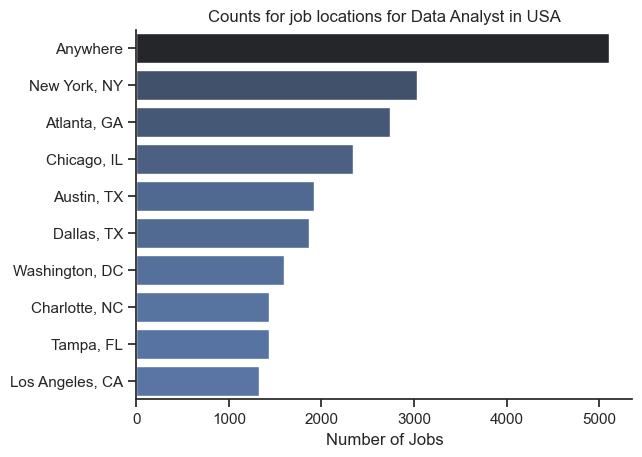

In [ ]:
# Job Locations

df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title("Counts for job locations for Data Analyst in USA")
plt.xlabel("Number of Jobs")
plt.ylabel('')
plt.show()

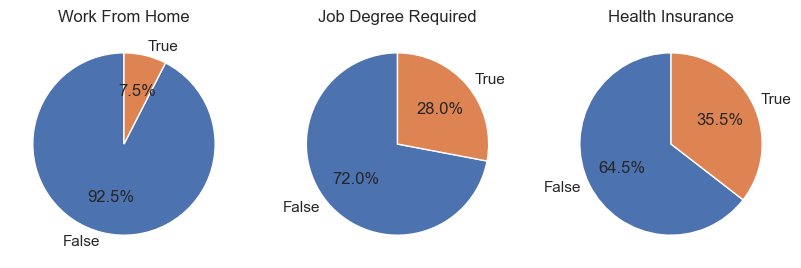

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(10,6))

dict_columns = {
    "job_work_from_home": "Work From Home",
    "job_no_degree_mention": "Job Degree Required",
    "job_health_insurance": "Health Insurance"
}

for i ,(column, title) in enumerate(dict_columns.items()):
    df_DA_US[column].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[i])
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    

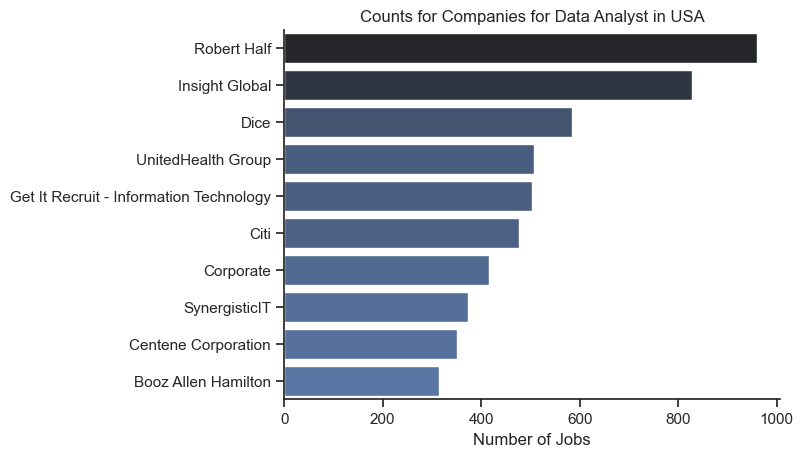

In [37]:
# Company Name

df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title("Counts for Companies for Data Analyst in USA")
plt.xlabel("Number of Jobs")
plt.ylabel('')
plt.show()